<a href="https://colab.research.google.com/github/Carrinson/collab-files/blob/main/Timeseries(MA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
import pandas as pd


           0
0  -0.052087
1   0.087923
2   0.257622
3   0.296847
4   0.184962
5   0.172058
6  -0.308097
7  -0.167916
8   0.014315
9  -0.041200
10 -0.095796
11 -0.155818
12 -0.275741
13 -0.130220
14 -0.100047
15 -0.157849
16 -0.201928
17 -0.104358
18  0.210617
19 -0.032921


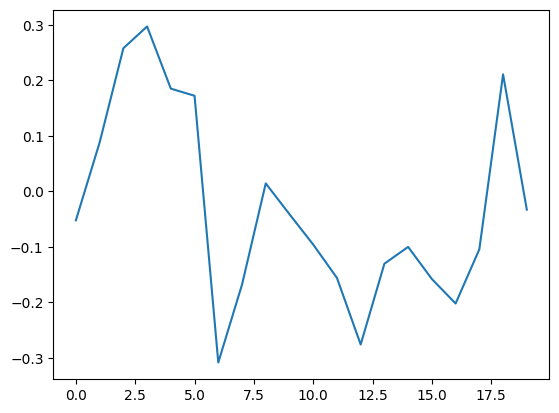

In [47]:
ar = np.array([7]) # dont do for real data
ma = np.array([1, 0.5])# dont do for real data

ma_data = ArmaProcess(ar, ma) # dont do for real data

# print(ma_data)

df = ma_data.generate_sample(nsample=20) # dont do for real data
df = pd.DataFrame(df)
print(df)
plt.plot(df)

In [48]:
from statsmodels.tsa.stattools import adfuller

In [49]:
price_test_stationary = adfuller(df)

In [50]:
print(f"The value is {price_test_stationary[0]}")
print(f"the p value {price_test_stationary[1]}")

The value is -25.911288371855264
the p value 0.0


In [51]:
log_returns = np.log(df / df.shift(1))

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [52]:
log_returns.isna().sum()

,0
0,7


In [53]:
log_returns.dropna(inplace=True)

In [54]:
log_returns.isna().sum()

,0
0,0


In [55]:
print(log_returns)

           0
2   1.075035
3   0.141724
4  -0.473065
5  -0.072319
7  -0.606951
10  0.843791
11  0.486468
12  0.570773
13 -0.750234
14 -0.263586
15  0.455996
16  0.246275
17 -0.660087


In [56]:
data2 = log_returns[0].tolist()

log_returns_test_stationary = adfuller(data2)

In [57]:

print(f"The value is {log_returns_test_stationary[0]}")
print(f"the p value {log_returns_test_stationary[1]}")

The value is -3.0927734334170673
the p value 0.027092629683301433


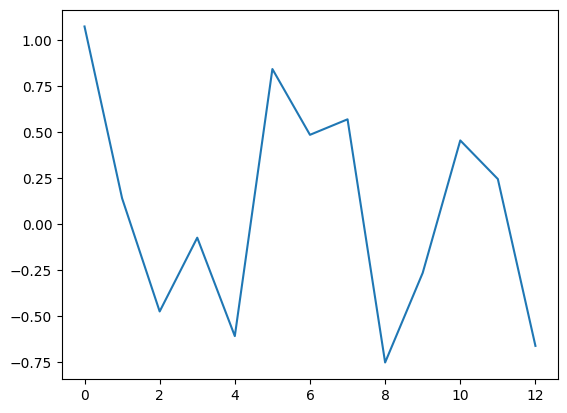

In [58]:
df2 = pd.DataFrame(data2)

plt.plot(df2)

In [59]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df2, order =(0,0,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   13
Model:                 ARIMA(0, 0, 1)   Log Likelihood                  -9.679
Date:                Thu, 11 Jun 2026   AIC                             25.357
Time:                        14:00:11   BIC                             27.052
Sample:                             0   HQIC                            25.009
                                 - 13                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0689      0.039      1.760      0.078      -0.008       0.146
ma.L1         -0.9999   1354.099     -0.001      0.999   -2654.985    2652.986
sigma2         0.2119    286.803      0.001      0.9

In [60]:
model_fit.forecast(steps=4)

,predicted_mean
13,0.541933
14,0.068940
15,0.068940
16,0.068940
